In [15]:
from locallib.picarrodb import *
from locallib.query import *
import pandas as pd

In [16]:
a = get_users(customer_name = 'ENBW', user_table = '#TempUser')
b = get_surveys(user_table = '#TempUser', survey_table = '#TempSurvey', start_date = '2025-10-01', end_date = '2026-07-01')
b.set_child(Query(
    query = (
        "SELECT "
        "COUNT(P.Id) AS PeakCount, "
        "P.SurveyId, "
        "SQA.AverageFlowRate "
        "INTO #TempPeak "
        "FROM Peak P "
        "LEFT JOIN SurveyQACheck SQA ON P.SurveyId = SQA.SurveyId "
        "WHERE P.SurveyId IN (SELECT SurveyId FROM #TempSurvey) "
   
        "GROUP BY P.SurveyId, SQA.AverageFlowRate"
    )
))
a.set_child(b)
data = a.execute(EU1_Conn, table_return = ['#TempPeak', '#TempSurvey'])

In [17]:
peak_survey = pd.merge(data['#TempSurvey'][['SurveyId', 'SurveyorUnit','RawDurationMinutes','StartDateTime','EndDateTime']], data['#TempPeak'][['PeakCount', 'SurveyId', 'AverageFlowRate']], on = 'SurveyId', how = 'left')
peak_survey['AverageFlowRate'] = peak_survey['AverageFlowRate'].astype(float)
peak_survey = peak_survey.dropna(subset=['AverageFlowRate'])

In [18]:
peak_survey['PeakMinutes'] = peak_survey['PeakCount'] / peak_survey['RawDurationMinutes']

In [19]:
import numpy as np
import matplotlib.pyplot as plt

class FixedVarianceAsymmetricDetector2D:
    def __init__(self, step_threshold_z=3.5, exp_collapse_floor=0.15, warmup_period=20):
        """
        step_threshold_z: Z-score multiplier for the mean shift in Signal A.
        exp_collapse_floor: The near-zero bound for Signal B.
        warmup_period: Iterations used to lock down the baseline standard deviation.
        """
        self.threshold_z = step_threshold_z
        self.exp_floor = exp_collapse_floor
        self.warmup = warmup_period
        
        self.count = 0
        self.step_mean = 0.0
        self.step_M2 = 0.0
        self.step_std = None  # Will be locked after warmup
        self.last_step_z_score = np.nan

        self.exp_mean = 0.0
        self.exp_M2 = 0.0
        self.exp_count = 0
        self.exp_std = np.nan

    def _update_exp_stats(self, val_exp):
        self.exp_count += 1
        delta_exp = val_exp - self.exp_mean
        self.exp_mean += delta_exp / self.exp_count
        self.exp_M2 += delta_exp * (val_exp - self.exp_mean)
        if self.exp_count >= 2:
            self.exp_std = max((self.exp_M2 / (self.exp_count - 1)) ** 0.5, 1e-6)

    def process_point(self, val_step, val_exp):
        """Processes exactly ONE incoming real-time point."""
        self.count += 1
        self._update_exp_stats(val_exp)

        # 1. Warmup Phase: Learn the stable standard deviation of Signal A
        if self.count <= self.warmup:
            delta = val_step - self.step_mean
            self.step_mean += delta / self.count
            self.step_M2 += delta * (val_step - self.step_mean)
            
            if self.count == self.warmup:
                # Lock the variance and standard deviation here
                variance = self.step_M2 / (self.warmup - 1)
                self.step_std = max(variance ** 0.5, 1e-6)
            self.last_step_z_score = np.nan
            return "WARMUP"

        # 2. Evaluate Signal A using the locked historical standard deviation
        # This keeps the math stable even if the mean shifts aggressively
        step_z_score = (val_step - self.step_mean) / self.step_std
        self.last_step_z_score = step_z_score

        # 3. Evaluate Signal B (Exponential collapse tracking)
        is_exp_collapsing = 0 <= val_exp <= self.exp_floor

        # 4. Instant Dual-Trigger Condition
        if step_z_score > self.threshold_z and is_exp_collapsing:
            return "EVENT_DETECTED"
        
        # Update the mean baseline for Signal A only if it's a normal point
        # to prevent baseline pollution
        delta = val_step - self.step_mean
        self.step_mean += delta / (self.count - self.warmup + 1)
        return "NORMAL"


In [20]:
# Sort the dataframe by 'Time' before extracting the relevant signals
cupra_survey = peak_survey[peak_survey['SurveyorUnit'].str.contains('Cupra')].sort_values('StartDateTime')
sig_step = cupra_survey['AverageFlowRate'].to_numpy()
sig_exp = cupra_survey['PeakMinutes'].to_numpy()
detector = FixedVarianceAsymmetricDetector2D(step_threshold_z=1.9, exp_collapse_floor=0.15, warmup_period=20)
detected_idx = None
z_scores = []
exp_sigmas = []

for t in range(len(sig_step)):
    status = detector.process_point(sig_step[t], sig_exp[t])
    z_scores.append(detector.last_step_z_score)
    exp_sigmas.append(detector.exp_std)
    if status == "EVENT_DETECTED" and detected_idx is None:
        detected_idx = t
        print(f"💥 [Step {t}] INSTANT EVENT DETECTED!")
        print(f"   -> Locked Noise Baseline (Std Dev): {detector.step_std:.2f}")
        print(f"   -> Signal A Mean Jumped to: {sig_step[t]:.2f}")
        print(f"   -> Signal B Collapsed to: {sig_exp[t]:.4f}")

💥 [Step 87] INSTANT EVENT DETECTED!
   -> Locked Noise Baseline (Std Dev): 0.04
   -> Signal A Mean Jumped to: 4.12
   -> Signal B Collapsed to: 0.1115


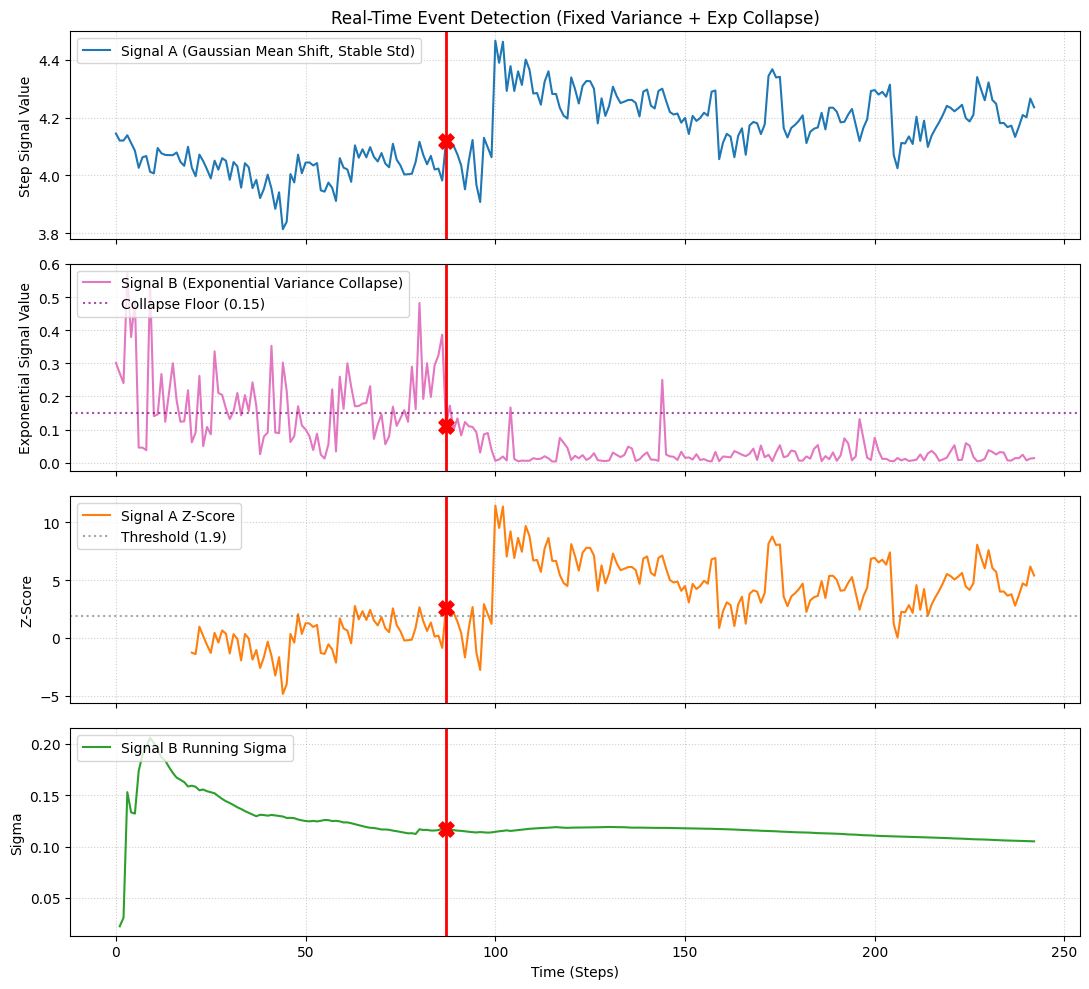

In [21]:
# --- Generate the Visualization ---
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

# Signal A Subplot
ax1.plot(sig_step, color="#1f77b4", linewidth=1.5, label="Signal A (Gaussian Mean Shift, Stable Std)")
ax1.set_title("Real-Time Event Detection (Fixed Variance + Exp Collapse)")
ax1.set_ylabel("Step Signal Value")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left")

# Signal B Subplot
ax2.plot(sig_exp, color="#e377c2", linewidth=1.5, label="Signal B (Exponential Variance Collapse)")
ax2.axhline(y=0.15, color="purple", linestyle=":", alpha=0.7, label="Collapse Floor (0.15)")
ax2.set_ylabel("Exponential Signal Value")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper left")

# Z-Score Subplot
ax3.plot(z_scores, color="#ff7f0e", linewidth=1.5, label="Signal A Z-Score")
ax3.axhline(y=detector.threshold_z, color="gray", linestyle=":", alpha=0.7, label=f"Threshold ({detector.threshold_z})")
ax3.set_ylabel("Z-Score")
ax3.grid(True, linestyle=":", alpha=0.6)
ax3.legend(loc="upper left")

# Signal B Sigma Subplot
ax4.plot(exp_sigmas, color="#2ca02c", linewidth=1.5, label="Signal B Running Sigma")
ax4.set_ylabel("Sigma")
ax4.set_xlabel("Time (Steps)")
ax4.grid(True, linestyle=":", alpha=0.6)
ax4.legend(loc="upper left")

if detected_idx is not None:
    # Anchor the exact step point across all charts
    for ax in (ax1, ax2, ax3, ax4):
        ax.axvline(x=detected_idx, color="red", linestyle="-", linewidth=2)

    ax1.scatter(detected_idx, sig_step[detected_idx], color="red", marker="X", s=120, zorder=5)
    ax2.scatter(detected_idx, sig_exp[detected_idx], color="red", marker="X", s=120, zorder=5)
    ax3.scatter(detected_idx, z_scores[detected_idx], color="red", marker="X", s=120, zorder=5)
    ax4.scatter(detected_idx, exp_sigmas[detected_idx], color="red", marker="X", s=120, zorder=5)

plt.tight_layout()
plt.show()